In [5]:
# =========================================================
# 03_modeling.ipynb | Full Modeling & Comparison
# =========================================================
import os
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

# ---------------------------------------------------------
# 1) Load Processed Data (CSV) And Save Plots
# ---------------------------------------------------------
ROOT = Path().resolve().parent  # یک پوشه بالاتر از notebooks

DATA_DIR = ROOT / "data" / "processed"
DATA_DIR.mkdir(parents=True, exist_ok=True)

save_dir = ROOT / "reports" / "figures"
save_dir.mkdir(parents=True, exist_ok=True)


X_train = pd.read_csv(DATA_DIR / "X_train_processed.csv")
X_test  = pd.read_csv(DATA_DIR / "X_test_processed.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv").squeeze()
y_test  = pd.read_csv(DATA_DIR / "y_test.csv").squeeze()

# ---------------------------------------------------------
# 2) Utility: Evaluation Function (compat with old sklearn)
# ---------------------------------------------------------
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)   # بدون squared
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

# ---------------------------------------------------------
# 3) Define Models
# ---------------------------------------------------------
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.001, random_state=42),
    "DecisionTree": DecisionTreeRegressor(max_depth=6, random_state=42),
    "RandomForest": RandomForestRegressor(
        n_estimators=200, max_depth=8, random_state=42, n_jobs=-1
    )
}

# ---------------------------------------------------------
# 4) Train & Evaluate
# ---------------------------------------------------------
results = []
for name, model in models.items():
    metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
    results.append({"Model": name, **metrics})

results_df = pd.DataFrame(results).sort_values(by="RMSE")
print(results_df)




              Model           MAE          RMSE        R2
0  LinearRegression  9.700434e+05  1.324507e+06  0.652924
2             Lasso  9.700434e+05  1.324507e+06  0.652924
1             Ridge  9.702457e+05  1.325320e+06  0.652498
4      RandomForest  1.022419e+06  1.399992e+06  0.612236
3      DecisionTree  1.254703e+06  1.645653e+06  0.464213


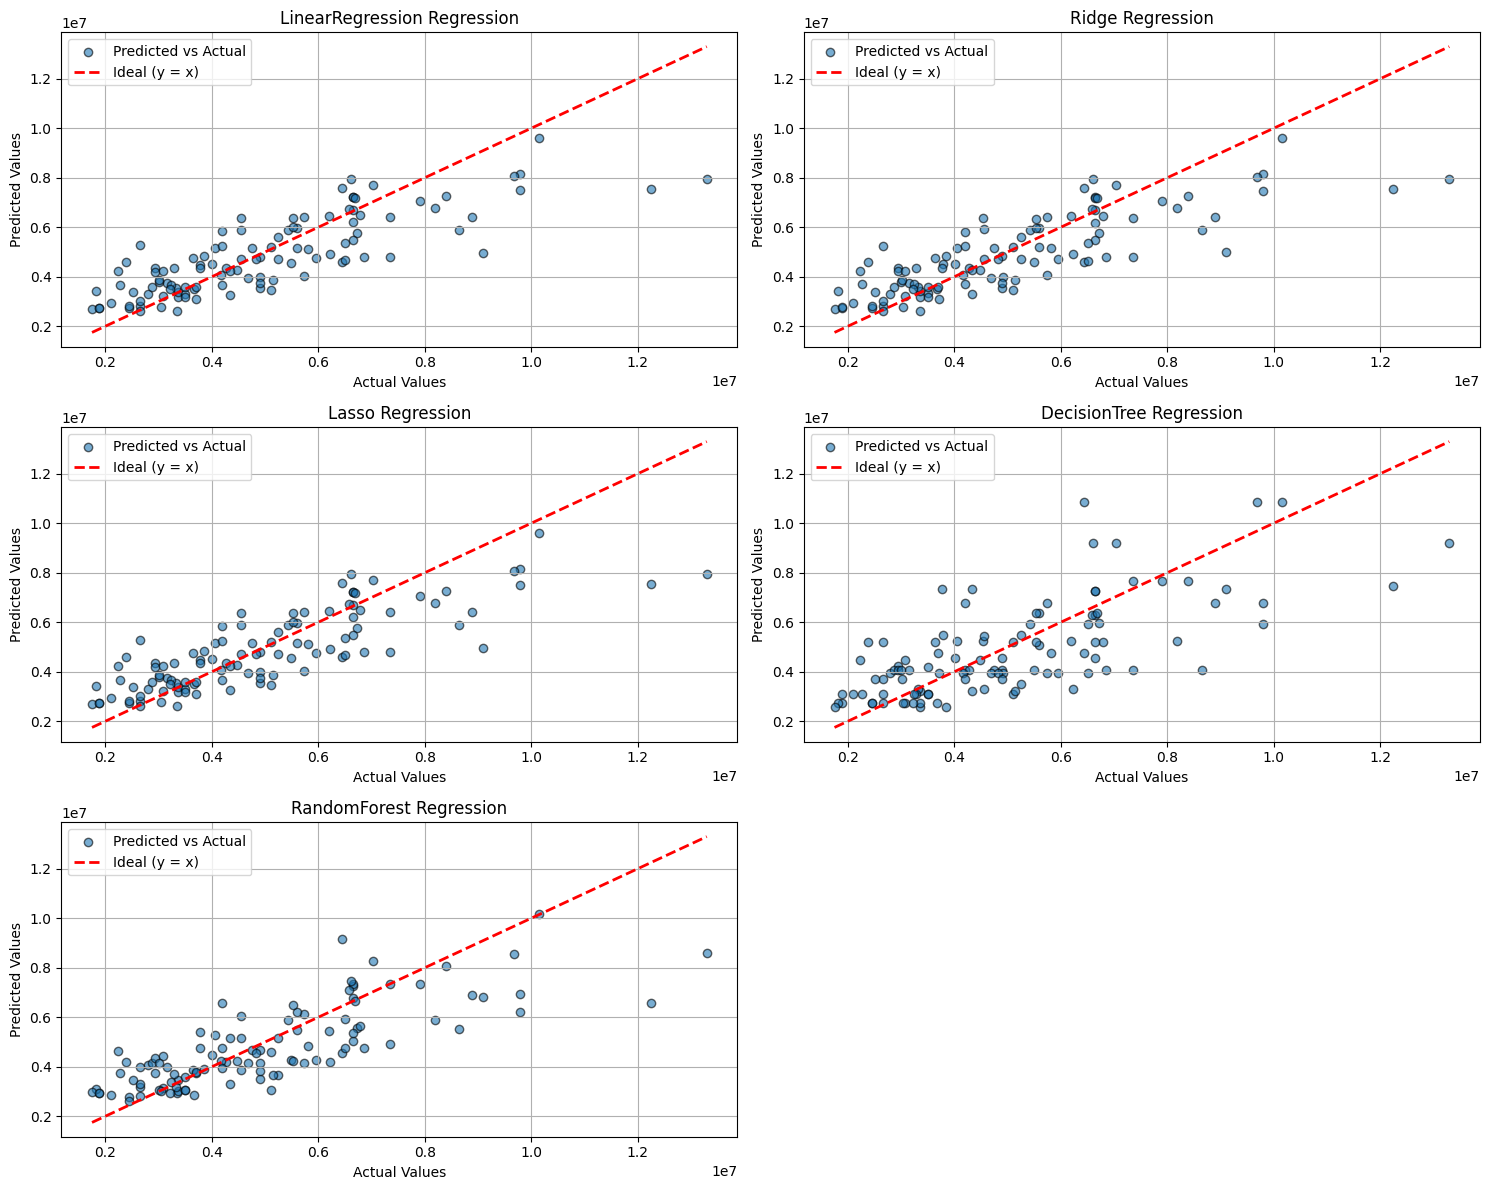

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12))

for i, (name, model) in enumerate(models.items(), 1):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    plt.subplot(3, 2, i)
    plt.scatter(y_test, preds, alpha=0.6, edgecolor='k', label='Predicted vs Actual')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal (y = x)')
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"{name} Regression")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "Rgressions.png"), dpi=300, bbox_inches="tight")
plt.show()
